<a href="https://colab.research.google.com/github/osamuelmarlon/credit-card-fraud-detection/blob/main/Detec%C3%A7%C3%A3o_de_Fraude_em_Cart%C3%B5es_de_Cr%C3%A9dito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
*by [Samuel Costa](https://www.linkedin.com/in/samuel-marlon-lopes-costa/)*

---

# Detecção de Fraudes em Cartões de Crédito


<p align=center>
<img src="https://ai-journey.com/wp-content/uploads/2019/06/fraud-EMV-chip-credit-card.jpg" width="32%"></p>

Neste projeto, construímos um pipeline completo de detecção de fraudes com foco em boas práticas como separação correta entre treino, validação e teste, normalização sem data leakage, tratamento do desbalanceamento extremo de classes e calibração de probabilidades, avaliado pelas métricas corretas para esse tipo de problema.

## Resumo Executivo

**Objetivo:** construir um pipeline de classificação para detecção de transações fraudulentas em cartões de crédito, com ênfase em boas práticas de modelagem e métricas adequadas ao problema.

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud): 284.807 transações reais anonimizadas via PCA, com desbalanceamento extremo de classes (0,17% de fraudes).

---

### Pipeline

| Etapa | Decisão |
|---|---|
| Separação dos dados | Train / Validation / Test com stratified split |
| Duplicatas | Investigadas e removidas (1.081 registros, incluindo fraudes) |
| Normalização | RobustScaler em `Amount` e `Time` (robusto a outliers) |
| Desbalanceamento | `class_weight='balanced'` na Regressão Logística |
| Calibração | `CalibratedClassifierCV` com método isotônico |
| Threshold | Otimizado por F1-score na validação, fixo no teste |

---

### Principais desafios

**Desbalanceamento extremo:** apenas 492 fraudes em 284.807 transações exigiu tratamento cuidadoso tanto na separação estratificada dos dados quanto na escolha do algoritmo e das métricas de avaliação.

**Probabilidades mal calibradas:** a Regressão Logística sem calibração produzia probabilidades comprimidas, resultando em threshold ótimo de 0.99, inviável na prática. A calibração isotônica corrigiu isso, trazendo o threshold para 0.45.

**Escolha de métricas:** acurácia e AUC-ROC são enganosas em datasets desbalanceados. O projeto foi avaliado por AUC-PR e F1-score, que refletem a qualidade real das detecções da classe minoritária.

---

### Resultado final: conjunto de teste

| Métrica | Valor |
|---|---|
| AUC-PR | 0.83 |
| AUC-ROC | 0.99 |
| Precision (fraude) | 91.94% |
| Recall (fraude) | 80.28% |
| F1-score (fraude) | 0.857 |
| Falsos positivos | 5 |
| Fraudes detectadas | 57 de 71 |

De 71 fraudes no conjunto de teste, o modelo detectou 57 gerando apenas 5 falsos alarmes. Ou seja, a cada 62 alertas disparados, 57 são fraudes reais. Esse nível de precisão torna o modelo operacionalmente viável para uso em produção.

## Importação de pacotes
Importação e organização de todas as dependências utilizadas no projeto.

In [1]:
#@title
# suprimir os warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

# Desinstala a versão atual e instala uma compatível
!pip uninstall -y scikit-plot
!pip install scikit-plot==0.3.7

In [2]:
# Manipulação e análise de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e modelagem
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

# Métricas de avaliação
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    PrecisionRecallDisplay
)

# Configuração dos gráficos
sns.set_style('dark')

Para facilitar a aquisição dos dados, criou-se um *link* com acesso direto ao `csv`. Com isso, basta importar o conjunto de dados usando o método `pd.read_csv()`.

In [3]:
file_path = "https://www.dropbox.com/s/b44o3t3ehmnx2b7/creditcard.csv?dl=1"

# importar os dados para um dataframe
df = pd.read_csv(file_path)


##**Investigação: Duplicatas na classe de fraude**

In [4]:
# ── Verifica Quantidade de Duplicadas ────────
print("Total de registros duplicados:", df.duplicated().sum())

# ── Isola apenas as fraudes do dataset original ──────────────
fraudes = df[df['Class'] == 1]
print("Total de fraudes antes de remover duplicatas:", len(fraudes))

# ── Identifica duplicatas perfeitas entre as fraudes ─────────
fraudes_duplicadas = fraudes[fraudes.duplicated(keep=False)]
print("Fraudes envolvidas em duplicatas perfeitas:", len(fraudes_duplicadas))

# ── Quantos registros únicos existem entre essas duplicatas ──
fraudes_dup_unicas = fraudes[fraudes.duplicated(keep='first')]
print("Registros de fraude que são cópias exatas:", len(fraudes_dup_unicas))

# ── Inspeciona os grupos duplicados ──────────────────────────
print("\nGrupos de fraudes duplicadas:")
print(fraudes_duplicadas.sort_values(by=list(fraudes.columns)).to_string())


Total de registros duplicados: 1081
Total de fraudes antes de remover duplicatas: 492
Fraudes envolvidas em duplicatas perfeitas: 32
Registros de fraude que são cópias exatas: 19

Grupos de fraudes duplicadas:
            Time         V1         V2         V3         V4         V5        V6         V7         V8        V9        V10       V11        V12       V13        V14       V15        V16        V17       V18       V19       V20        V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
102441   68207.0 -13.192671  12.785971  -9.906650   3.320337  -4.801176  5.760059 -18.750889 -37.353443 -0.391540  -5.052502  4.406806  -4.610756 -1.909488  -9.072711 -0.226074  -6.211557  -6.248145 -3.149247  0.051576 -3.493050  27.202839 -8.887017  5.303607 -0.639435  0.263203 -0.108877  1.269566  0.939407    1.00      1
102442   68207.0 -13.192671  12.785971  -9.906650   3.320337  -4.801176  5.760059 -18.750889 -37.353443 -0.391540  -5.052502  4.406806  -4.6

**Análise do output**

O padrão é inequívoco. Todos os 32 registros envolvidos são duplicatas perfeitas em todas as features, incluindo Time e Amount.

Transações reais, mesmo fraudulentas e repetidas pelo mesmo fraudador, dificilmente teriam valores PCA idênticos em todas as 28 componentes simultaneamente. Isso é ruído de coleta.

**Decisão**

Remover todas as duplicatas, incluindo as de fraude. Manter seria inflar artificialmente o peso de 9 padrões específicos de fraude no treino, o que é pior do que perder 19 registros.

## **Remoção de duplicatas e Split para o Teste**

In [5]:
# ── Remoção de duplicatas ────────────────────────────────────
df = df.drop_duplicates()
print("Shape após remoção de duplicatas:", df.shape)

# ── Split: separa teste (15%) e restante (85%) ───────────────
df_temp, test = train_test_split(
    df,
    test_size=0.15,
    random_state=0,
    stratify=df['Class']
)

# ── Verificação ──────────────────────────────────────────────
for nome, conjunto in [('Restante (treino+val)', df_temp), ('Teste', test)]:
    total = len(conjunto)
    fraudes = conjunto['Class'].sum()
    pct = (fraudes / total * 100).round(4)
    print(f"{nome}: {total} linhas | {fraudes} fraudes ({pct}%)")


Shape após remoção de duplicatas: (283726, 31)
Restante (treino+val): 241167 linhas | 402 fraudes (0.1667%)
Teste: 42559 linhas | 71 fraudes (0.1668%)


Com os dados importados para dentro de uma estrutura *Dataframe* - e não havendo a necessidade de mais nenhum ajuste ou configuração nesta etapa, pode-se iniciar uma análise exploratória dos dados a fim de preparar um modelo de *Machine Learning*.


Feito isso, vamos à Análise Exploratória.

## **Análise Exploratória**

## **Resumo estatístico do dataframe**

In [6]:
df_temp.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,...,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000,241167.000000
mean,94749.667301,0.007571,-0.002647,0.002812,-0.006155,0.000482,0.000542,0.001667,-0.000221,-0.002335,...,-0.000435,-0.000540,0.000319,0.000430,0.000003,0.000694,0.001239,0.000946,88.363626,0.001667
std,47483.152456,1.938602,1.632307,1.506133,1.411466,1.377549,1.332861,1.230299,1.176371,1.096421,...,0.722468,0.723397,0.621203,0.605316,0.520361,0.482463,0.396798,0.330702,248.643004,0.040794
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-9.499423,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54172.000000,-0.915731,-0.600533,-0.886910,-0.851736,-0.690581,-0.768281,-0.552264,-0.208386,-0.645969,...,-0.228432,-0.542371,-0.161651,-0.354452,-0.317028,-0.327080,-0.070597,-0.052697,5.590000,0.000000
50%,84618.000000,0.020127,0.063651,0.179953,-0.025393,-0.054318,-0.274787,0.039096,0.021826,-0.052724,...,-0.029618,0.005624,-0.011184,0.040837,0.016756,-0.051920,0.001429,0.011343,22.000000,0.000000
75%,139276.000000,1.315599,0.800161,1.026561,0.735987,0.611951,0.395091,0.568981,0.326376,0.595684,...,0.185725,0.527319,0.147697,0.439495,0.350354,0.240468,0.091056,0.078510,77.500000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


## **Valores ausentes**

In [7]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241167 entries, 131105 to 2621
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    241167 non-null  float64
 1   V1      241167 non-null  float64
 2   V2      241167 non-null  float64
 3   V3      241167 non-null  float64
 4   V4      241167 non-null  float64
 5   V5      241167 non-null  float64
 6   V6      241167 non-null  float64
 7   V7      241167 non-null  float64
 8   V8      241167 non-null  float64
 9   V9      241167 non-null  float64
 10  V10     241167 non-null  float64
 11  V11     241167 non-null  float64
 12  V12     241167 non-null  float64
 13  V13     241167 non-null  float64
 14  V14     241167 non-null  float64
 15  V15     241167 non-null  float64
 16  V16     241167 non-null  float64
 17  V17     241167 non-null  float64
 18  V18     241167 non-null  float64
 19  V19     241167 non-null  float64
 20  V20     241167 non-null  float64
 21  V21     2411

Nenhuma coluna com dados ausentes

## **Balanceamento do dataset**

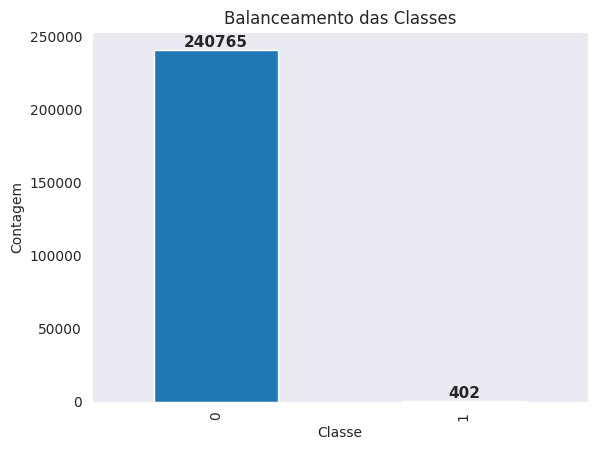

In [8]:
# Cria o gráfico de barras
ax = df_temp['Class'].value_counts().plot(kind='bar')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Balanceamento das Classes')

# Adiciona rótulos com a contagem em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{int(altura)}',
                (p.get_x() + p.get_width() / 2, altura),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

**Dataset totalmente desbalanceado**.

Essa característica deve ser levada em consideração para a escolha dos modelos e das métricas.

In [9]:
# Separando df com e sem fraude para análise exploratória

df_fraude = df_temp.loc[df['Class'] == 1]
df_sem_fraude = df_temp.loc[df['Class'] == 0]

## **Variável *Time* com e sem fraude**

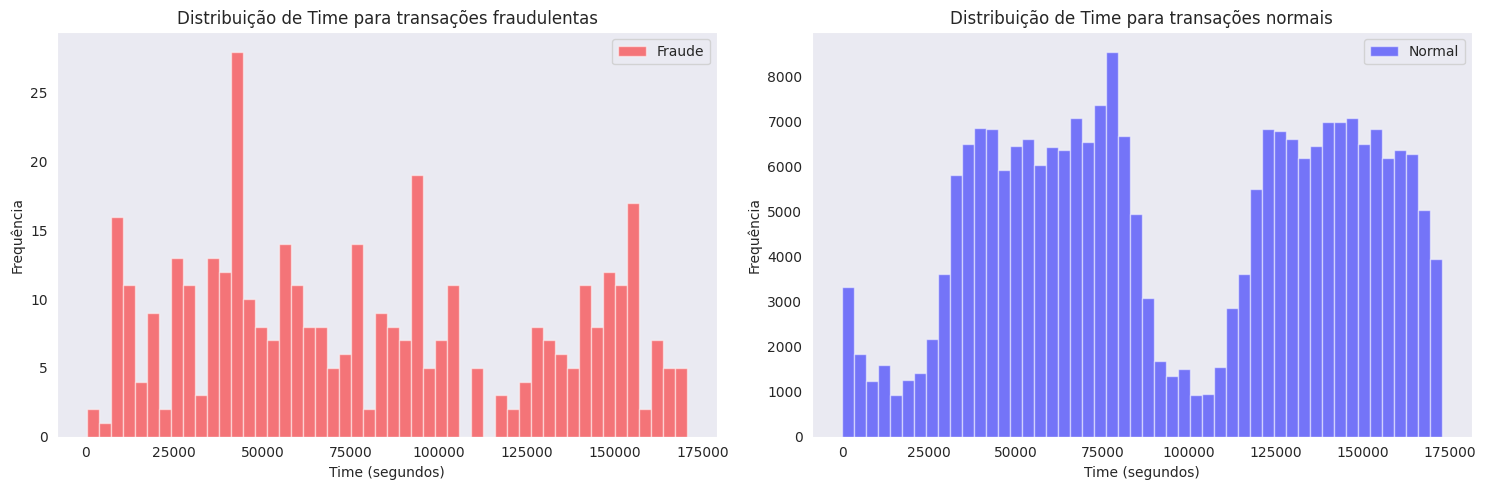

In [10]:
# histograma p/ Variável Time com e sem fraude

fig, ax = plt.subplots(1, 2, figsize=(15, 5)) # Cria 1 linha, 2 colunas de subplots

ax[0].hist(df_fraude.Time, bins=50, alpha=0.5, label='Fraude', color='red')
ax[0].set_title('Distribuição de Time para transações fraudulentas')
ax[0].set_xlabel('Time (segundos)')
ax[0].set_ylabel('Frequência')
ax[0].legend()

ax[1].hist(df_sem_fraude.Time, bins=50, alpha=0.5, label='Normal', color='blue')
ax[1].set_title('Distribuição de Time para transações normais')
ax[1].set_xlabel('Time (segundos)')
ax[1].set_ylabel('Frequência')
ax[1].legend()

plt.tight_layout()
plt.show()

**Valores frequentes sem fraude**



In [11]:
df_sem_fraude.Time.value_counts(normalize=True)

,proportion
Time,
3770.0,0.000075
3766.0,0.000066
3767.0,0.000066
3749.0,0.000066
3755.0,0.000062
...,...
143728.0,0.000004
70402.0,0.000004
26476.0,0.000004


**Valores frequentes com fraude**

In [12]:
df_fraude.Time.value_counts(normalize=True)

,proportion
Time,
93860.0,0.004975
85285.0,0.004975
84204.0,0.004975
129741.0,0.002488
158638.0,0.002488
...,...
169142.0,0.002488
85867.0,0.002488
73408.0,0.002488


Não há um intervalo claro em que “quase só ocorre fraude” ou “quase não ocorre fraude”. Isso indica que Time, sozinho, não separa bem fraude de normal.

## **Variável Amount com e sem fraude**

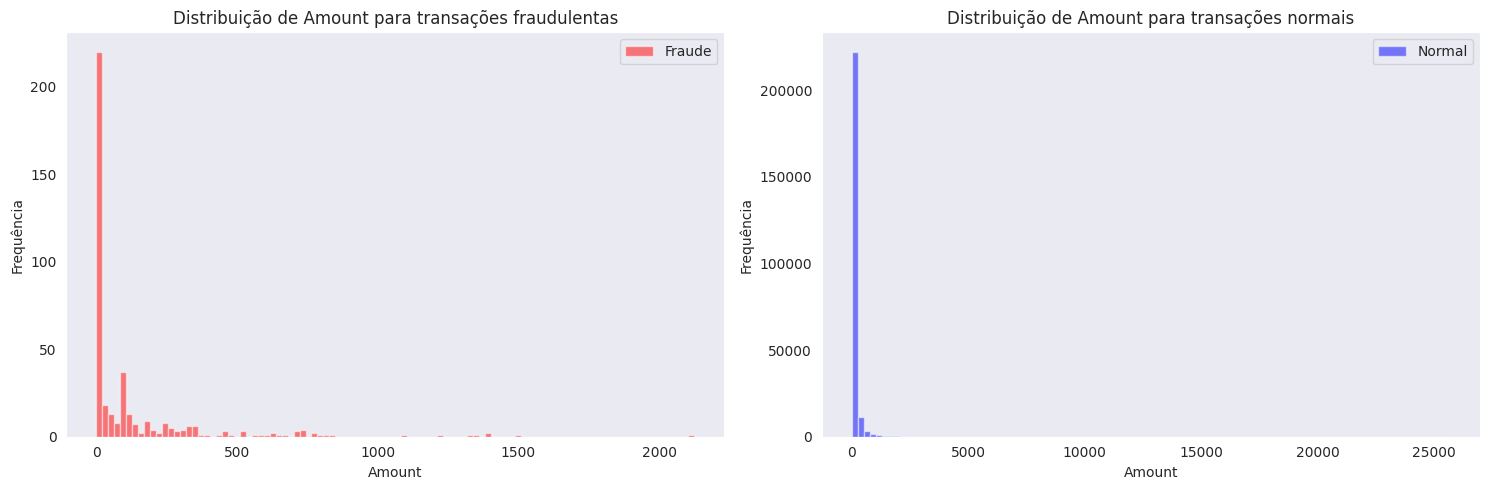

In [13]:
## histograma p/ Variável Amount com e sem fraude

fig, ax = plt.subplots(1, 2, figsize=(15, 5)) # Cria 1 linha, 2 colunas de subplots
ax[0].hist(df_fraude.Amount, bins=100, alpha=0.5, label='Fraude', color='red')
ax[0].set_title('Distribuição de Amount para transações fraudulentas')
ax[0].set_xlabel('Amount')
ax[0].set_ylabel('Frequência')
ax[0].legend()
ax[1].hist(df_sem_fraude.Amount, bins=100, alpha=0.5, label='Normal', color='blue')
ax[1].set_title('Distribuição de Amount para transações normais')
ax[1].set_xlabel('Amount')
ax[1].set_ylabel('Frequência')
ax[1].legend()
plt.tight_layout()
plt.show()

In [14]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


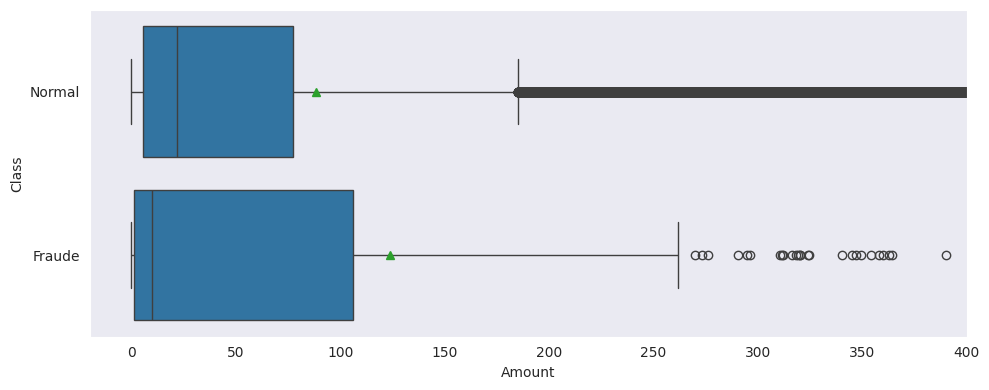

In [15]:
fig, ax = plt.subplots(figsize=(10, 4), sharex=True)

sns.boxplot(x='Amount', y='Class', data=df, showmeans=True, orient='h')

plt.xlim((-20, 400)) #limitei o eixo X em 400 para ser possível visualizar com detalhes, já que há muitos outliers
plt.yticks([0, 1], ['Normal', 'Fraude'])

plt.tight_layout()

Fraudes não aparecem muito em valores extremamente altos.


*   50% dos valores vão até 11;
*   75% dos valores vão até 106.



**Valores frequentes com fraude**

In [16]:
df_fraude.Amount.value_counts(normalize=True)

,proportion
Amount,
1.00,0.218905
0.00,0.054726
99.99,0.052239
0.76,0.032338
0.77,0.022388
...,...
144.62,0.002488
99.85,0.002488
45.64,0.002488


**Valores frequentes sem fraude**

In [17]:
df_sem_fraude.Amount.value_counts(normalize=True)

,proportion
Amount,
1.00,0.047748
1.98,0.021511
0.89,0.017203
9.99,0.016713
15.00,0.011655
...,...
238.23,0.000004
1258.80,0.000004
1394.60,0.000004


- 21% de todas as fraudes têm valor exatamente 1.

- 33% das fraudes são com valores `1.00`, `99.99` e `0.00`

**Fraudes:** distribuição de Amount com picos fortes em alguns valores específicos `(1.00, 99.99, 0.00, …)`.

**Normais:** distribuição bem mais suave e espalhada; nenhum valor domina tanto.

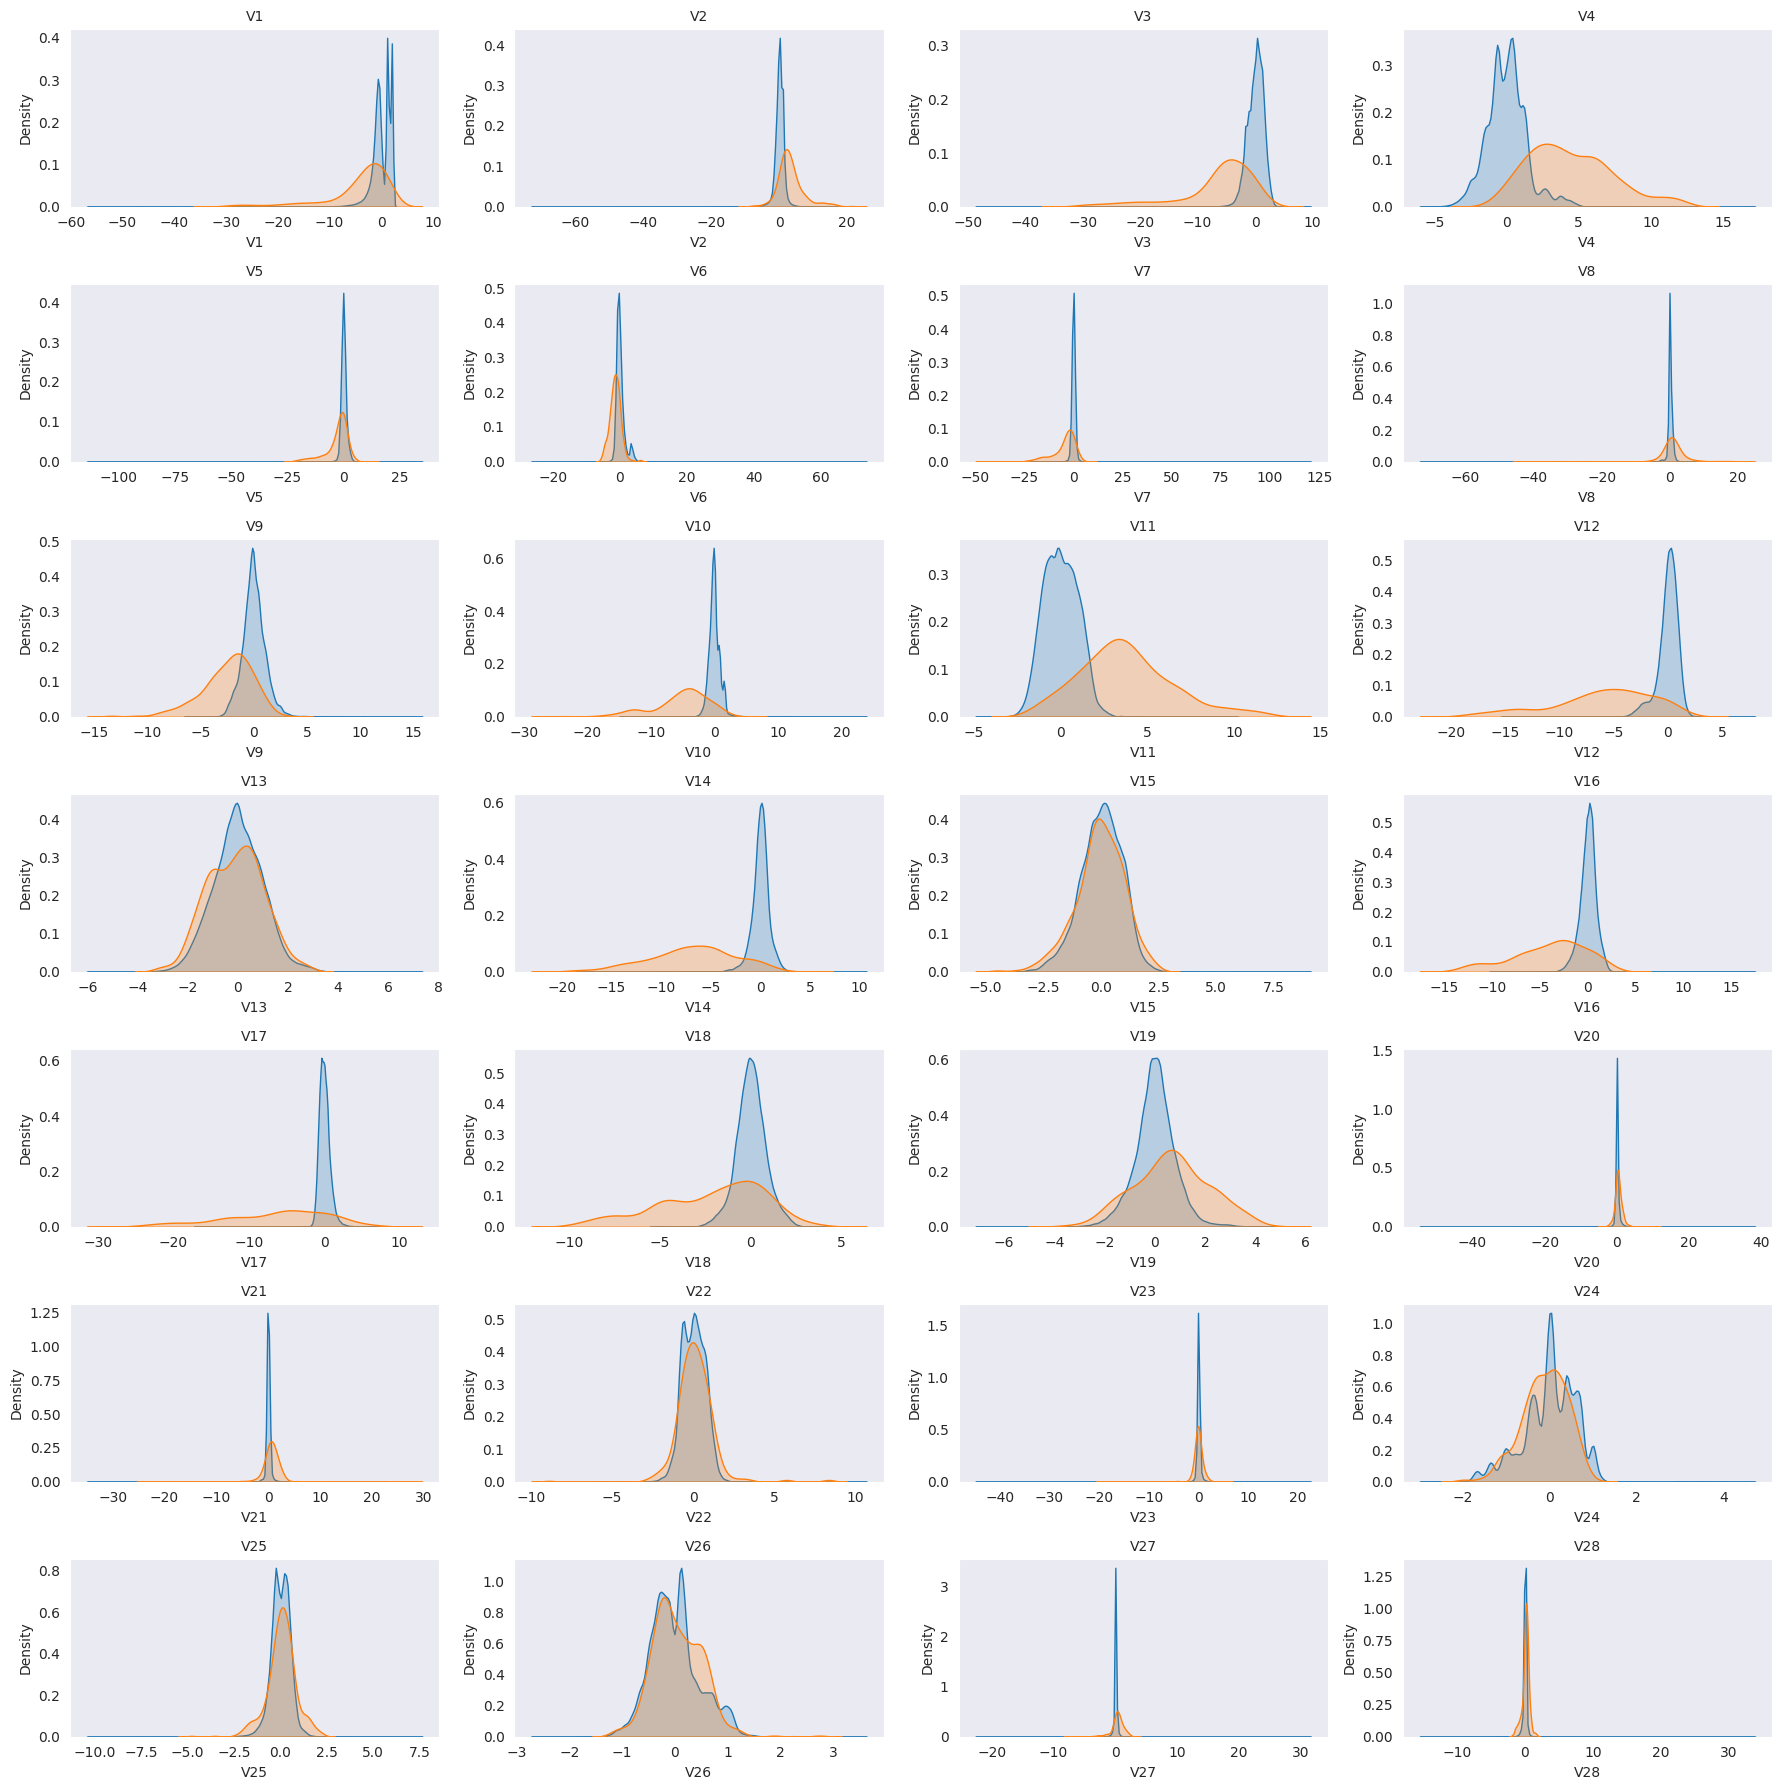

In [18]:
column_names = df_temp.drop(['Class', 'Amount', 'Time'], axis=1).columns
num_plots = len(column_names)
df_class_0 = df_temp[df_temp.Class == 0]
df_class_1 = df_temp[df_temp.Class == 1]

fig, ax = plt.subplots(nrows=7, ncols=4, figsize=(18,18))
fig.subplots_adjust(hspace=1, wspace=1)

idx = 0
for col in column_names:
    idx += 1
    plt.subplot(7, 4, idx)
    sns.kdeplot(df_class_0[col], label="Class 0", shade=True)
    sns.kdeplot(df_class_1[col], label="Class 1", shade=True)
    plt.title(col, fontsize=10)
plt.tight_layout()



O gráfico de densidade é muito útil para compararmos as distribuições de cada variável para cada classe e ver quais as mais importantes para detecção de anomalias.

Identifica-se que as variáveis `V3`, `V4`, `V10` e `V11` são bem distintas.

Por outro lado, as variáveis `V8`, `V13`, `V15`, `V20`, `V22`, `V23`, `V28` são muito similares, apresentando aproximadamente o mesmo comportamento.

## **Divisão dados de Trieno e Validação**
Usamos `stratify=df_temp['Class']` porque o problema é de classificação altamente desbalanceada (fraude vs. não fraude). A estratificação garante que as proporções de cada classe sejam mantidas tanto no treino quanto na validação, evitando que o conjunto de validação fique sem exemplos de fraude e tornando a avaliação mais realista.

In [19]:
# ── Split: treino (80%) e validação (20%) dentro do df_temp ──
train, val = train_test_split(
    df_temp,
    test_size=0.20,
    random_state=0,
    stratify=df_temp['Class']
)

# ── Verificação das proporções ───────────────────────────────
for nome, conjunto in [('Treino', train), ('Validação', val)]:
    total = len(conjunto)
    fraudes = conjunto['Class'].sum()
    pct = (fraudes / total * 100).round(4)
    print(f"{nome}: {total} linhas | {fraudes} fraudes ({pct}%)")

Treino: 192933 linhas | 322 fraudes (0.1669%)
Validação: 48234 linhas | 80 fraudes (0.1659%)


### **Normalizando os dados que ainda não foram pré-processados** (`Time` e `Amount`)

Usaremos **RobustScaler** por ser mais indicado em bases com muitos outliers, como é a o caso principalmente da feature `Amount`.

O RobustScaler do scikit-learn é um método de pré-processamento que dimensiona recursos (features) removendo a mediana e escalando com base no intervalo interquartil (IQR), tornando-o altamente resistente a outliers. Diferente do StandardScaler (média/desvio) ou MinMaxScaler.

In [20]:

# ── Separação de features (X) e target (y) ───────────────────
X_train = train.drop(columns='Class')
y_train = train['Class']

X_val = val.drop(columns='Class')
y_val = val['Class']

X_test = test.drop(columns='Class')
y_test = test['Class']

# ── RobustScaler fitado apenas no treino ─────────────────────
scaler = RobustScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_val[['Time', 'Amount']]   = scaler.transform(X_val[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])

# ── Verificação do scaler ────────────────────────────────────
print("\nEstatísticas de Time e Amount no treino após RobustScaler:")
print(X_train[['Time', 'Amount']].describe().round(4))




Estatísticas de Time e Amount no treino após RobustScaler:
              Time       Amount
count  192933.0000  192933.0000
mean        0.1191       0.9261
std         0.5577       3.5065
min        -0.9939      -0.3065
25%        -0.3580      -0.2285
50%         0.0000       0.0000
75%         0.6420       0.7715
max         1.0351     357.6088


## **Normalização: RobustScaler**

As features `Amount` e `Time` não passaram pelo PCA original do dataset e chegam em escalas muito diferentes das demais. Como os modelos escolhidos (Regressão Logística, SVM, KNN) são sensíveis à escala, a normalização é obrigatória.

O **RobustScaler** foi escolhido por usar mediana e IQR como referência. Ao contrário do StandardScaler, que usa média e desvio padrão, ele não é distorcido por outliers extremos, que existem em quantidade nessas duas features.

---

### **Por que o fit acontece apenas no treino?**

O `fit` é a etapa em que o scaler **aprende** as estatísticas necessárias para normalizar. No caso do RobustScaler, a mediana e o IQR de cada feature. Essas estatísticas se tornam a "régua" de transformação.

Essa régua deve ser aprendida **exclusivamente com os dados de treino** porque, na prática, validação e teste representam dados futuros, que o modelo ainda não viu. Se o scaler fosse fitado com esses dados incluídos, as estatísticas de normalização seriam influenciadas por informações que o modelo não deveria ter acesso naquele momento. Isso é chamado de **data leakage** e resulta em uma avaliação artificialmente otimista.

A mesma lógica vale para produção: o scaler é treinado uma vez, salvo junto com o modelo, e aplicado a qualquer dado novo que chegar, sem recalcular nada.

---

### `fit_transform` vs `transform`

| | O que faz |
|---|---|
| `fit_transform` | Aprende as estatísticas **e** transforma (usado no treino) |
| `transform` | Usa as estatísticas já aprendidas para transformar (usado em validação e teste) |

Chamar `transform` em validação e teste garante que os três conjuntos estão na **mesma escala**, definida pelo treino. Se cada conjunto fosse normalizado com suas próprias estatísticas, os valores perderiam consistência. O modelo foi treinado esperando que "0" signifique "na mediana do treino", e essa referência precisa ser mantida em todos os dados.

## **Modelo de Machine Learning**

In [21]:
# instanciar e treinar um modelo de Regressão Logística

# ── Treinamento ──────────────────────────────────────────────
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=0
)

model.fit(X_train, y_train)

# ── Predições na validação ───────────────────────────────────
y_pred       = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

## **Avaliar o desempenho do modelo**

In [22]:
# ── Métricas ─────────────────────────────────────────────────
print("Classification Report:")
print(classification_report(y_val, y_pred, digits=4))

print(f"AUC-ROC:  {roc_auc_score(y_val, y_pred_proba):.4f}")
print(f"AUC-PR:   {average_precision_score(y_val, y_pred_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9774    0.9884     48154
           1     0.0588    0.8500    0.1100        80

    accuracy                         0.9772     48234
   macro avg     0.5293    0.9137    0.5492     48234
weighted avg     0.9982    0.9772    0.9870     48234

AUC-ROC:  0.9717
AUC-PR:   0.7261


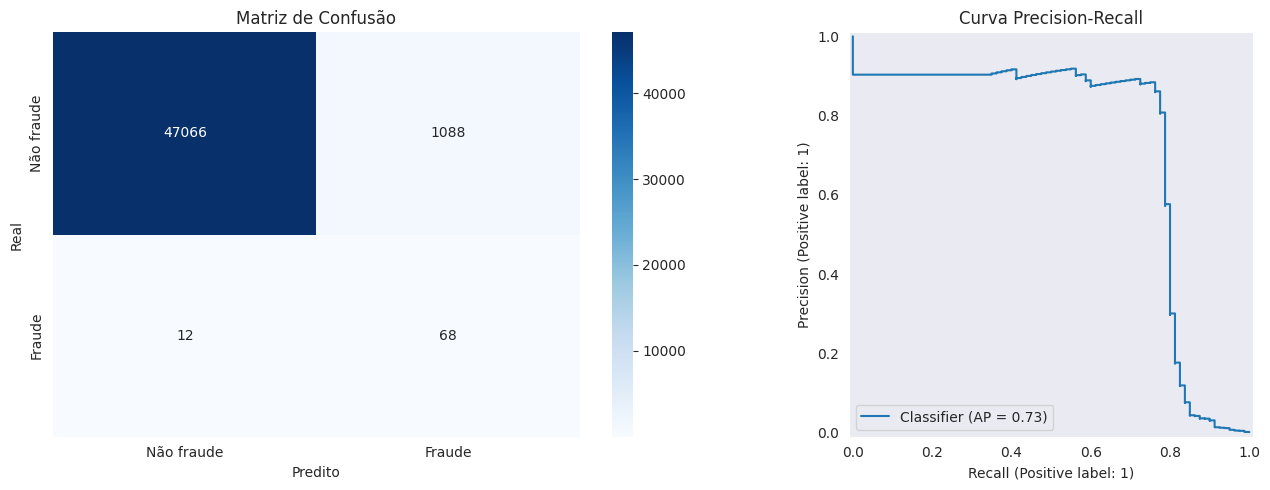

In [23]:
# ── Matriz de confusão ───────────────────────────────────────
cm = confusion_matrix(y_val, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não fraude', 'Fraude'],
            yticklabels=['Não fraude', 'Fraude'])
axes[0].set_title('Matriz de Confusão')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_val, y_pred_proba, ax=axes[1])
axes[1].set_title('Curva Precision-Recall')

plt.tight_layout()
plt.show()

## **Regressão Logística: Baseline**

Como ponto de partida, a Regressão Logística foi treinada com `class_weight='balanced'` e threshold padrão de 0.5.

O modelo apresentou AUC-ROC de 0.97 e AUC-PR de 0.73, números que indicam boa capacidade de discriminação. No entanto, a precision da classe fraude foi de apenas **5.88%**: de cada 100 alertas disparados, apenas 6 eram fraudes reais, gerando **1.088 falsos positivos** contra 68 detecções corretas. Operacionalmente, isso é inviável.

A raiz do problema estava nas **probabilidades mal calibradas**. O modelo distribuía as probabilidades de forma comprimida e a maioria das fraudes recebia scores baixos, e valores altos só apareciam em casos extremamente óbvios. Com isso, o threshold padrão de 0.5 funcionava como um critério frouxo demais, disparando alertas para qualquer transação com score minimamente elevado.

---


##**Ajuste de threshold via F1-score**

Threshold ótimo:  0.99
F1 no threshold ótimo: 0.6738

Classification Report com threshold ótimo:
              precision    recall  f1-score   support

           0     0.9996    0.9991    0.9994     48154
           1     0.5888    0.7875    0.6738        80

    accuracy                         0.9987     48234
   macro avg     0.7942    0.8933    0.8366     48234
weighted avg     0.9990    0.9987    0.9988     48234



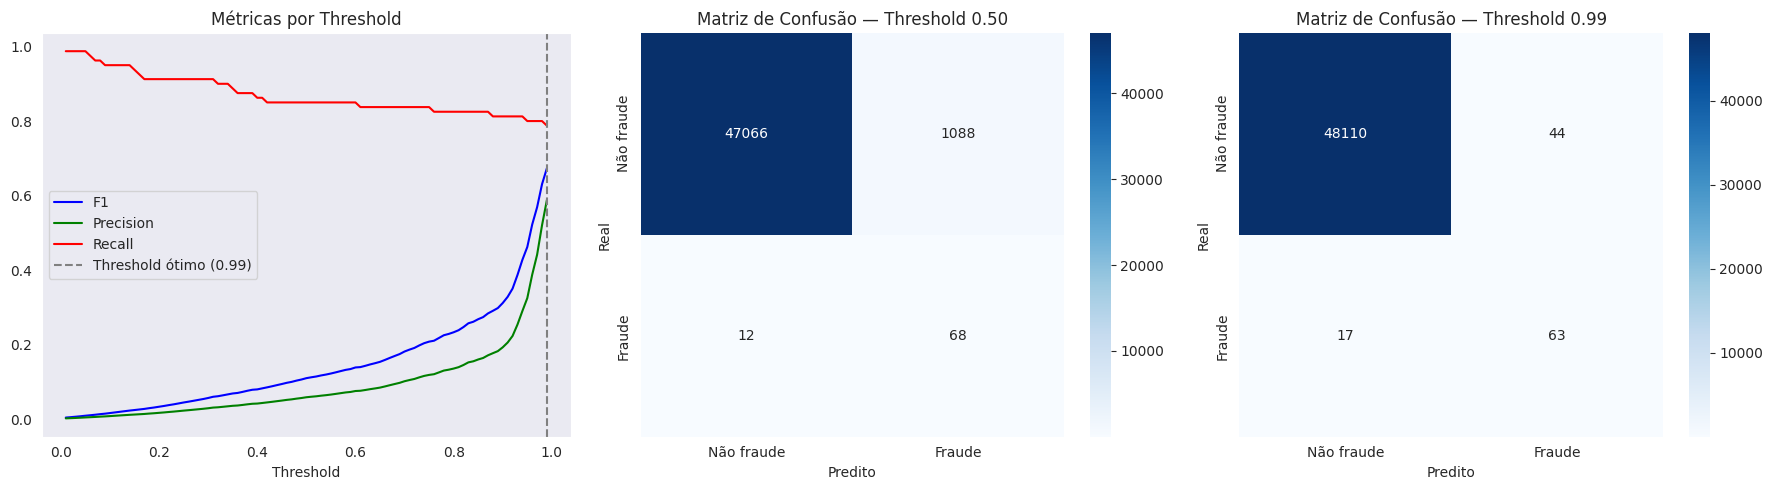

In [24]:
# ── Calcula métricas para cada threshold ─────────────────────
thresholds = np.arange(0.01, 1.00, 0.01)

f1_scores        = []
precision_scores = []
recall_scores    = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))
    precision_scores.append(precision_score(y_val, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_val, y_pred_t, zero_division=0))

# ── Threshold ótimo ──────────────────────────────────────────
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Threshold ótimo:  {best_threshold:.2f}")
print(f"F1 no threshold ótimo: {best_f1:.4f}")

# ── Métricas no threshold ótimo ──────────────────────────────
y_pred_best = (y_pred_proba >= best_threshold).astype(int)

print("\nClassification Report com threshold ótimo:")
print(classification_report(y_val, y_pred_best, digits=4))

cm_best = confusion_matrix(y_val, y_pred_best)

# ── Visualizações ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva de métricas por threshold
axes[0].plot(thresholds, f1_scores,        label='F1',        color='blue')
axes[0].plot(thresholds, precision_scores, label='Precision', color='green')
axes[0].plot(thresholds, recall_scores,    label='Recall',    color='red')
axes[0].axvline(best_threshold, color='gray', linestyle='--',
                label=f'Threshold ótimo ({best_threshold:.2f})')
axes[0].set_title('Métricas por Threshold')
axes[0].set_xlabel('Threshold')
axes[0].legend()

# Matriz de confusão — threshold padrão (0.5)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Não fraude', 'Fraude'],
            yticklabels=['Não fraude', 'Fraude'])
axes[1].set_title('Matriz de Confusão — Threshold 0.50')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

# Matriz de confusão — threshold ótimo
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Não fraude', 'Fraude'],
            yticklabels=['Não fraude', 'Fraude'])
axes[2].set_title(f'Matriz de Confusão — Threshold {best_threshold:.2f}')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Predito')

plt.tight_layout()
plt.show()

## **Ajuste de Threshold: Primeira Tentativa**

O problema identificado no baseline foi a precision baixa causada pelo threshold padrão de 0.5. A primeira abordagem para corrigir isso foi varrer todos os thresholds possíveis entre 0.01 e 0.99 e identificar aquele que maximiza o F1-score da classe fraude na validação.

O resultado foi um threshold ótimo de **0.99**, o que é um sinal de alerta, não uma solução. Um threshold tão extremo significa que o modelo só dispara alerta quando está quase absolutamente certo, o que na prática é frágil e instável. Qualquer pequena variação nos dados poderia fazer esse ponto ótimo desaparecer.

A causa raiz é que as **probabilidades estavam mal calibradas**: o modelo comprimia os scores em valores baixos, e só atribuía probabilidades altas em casos extremamente óbvios. Ajustar o threshold corrigiu o sintoma parcialmente, mas não resolveu o problema de origem.

A solução correta é calibrar as probabilidades primeiro, o que é feito na célula seguinte.

##**Calibração da Regressão Logística + XGBoost**


 Regressão Logística Calibrada
Threshold ótimo : 0.45
AUC-ROC         : 0.9715
AUC-PR          : 0.7434
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     48154
           1     0.8841    0.7625    0.8188        80

    accuracy                         0.9994     48234
   macro avg     0.9418    0.8812    0.9093     48234
weighted avg     0.9994    0.9994    0.9994     48234


 XGBoost
Threshold ótimo : 0.87
AUC-ROC         : 0.9640
AUC-PR          : 0.7251
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     48154
           1     0.8696    0.7500    0.8054        80

    accuracy                         0.9994     48234
   macro avg     0.9346    0.8749    0.9025     48234
weighted avg     0.9994    0.9994    0.9994     48234



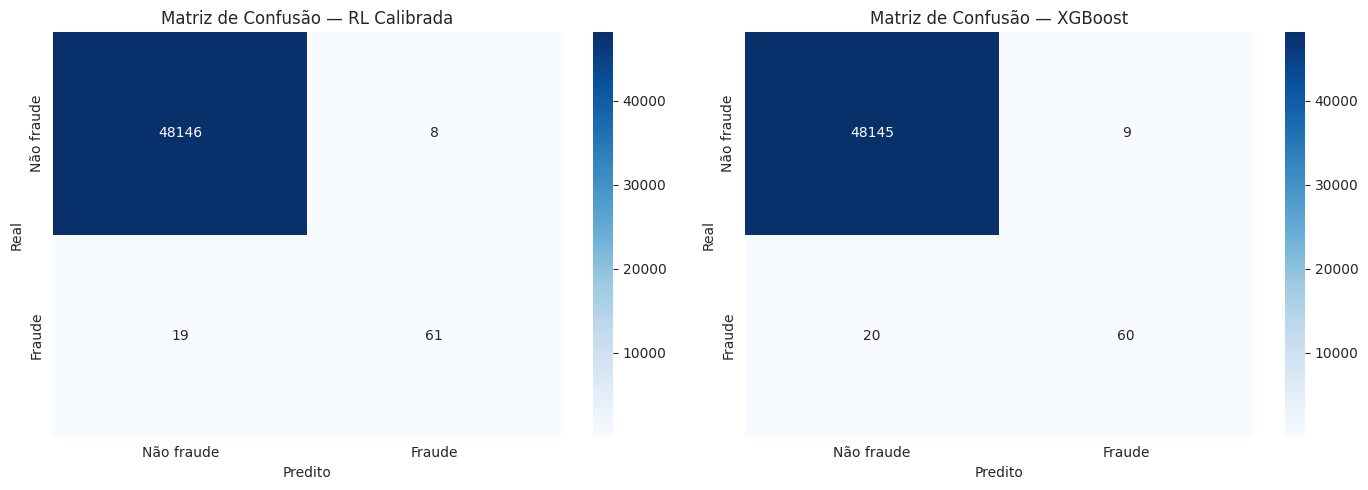

In [25]:

# ── Função auxiliar: busca threshold ótimo por F1 ────────────
def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.01, 1.00, 0.01)
    f1_scores  = [f1_score(y_true, (y_proba >= t).astype(int),
                           zero_division=0) for t in thresholds]
    best_idx   = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

# ── Função auxiliar: avalia modelo ───────────────────────────
def evaluate_model(name, y_true, y_proba):
    threshold, _ = find_best_threshold(y_true, y_proba)
    y_pred       = (y_proba >= threshold).astype(int)
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(f"Threshold ótimo : {threshold:.2f}")
    print(f"AUC-ROC         : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"AUC-PR          : {average_precision_score(y_true, y_proba):.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    return threshold, y_pred

# ────────────────────────────────────────────────────────────
# 1. REGRESSÃO LOGÍSTICA CALIBRADA
# ────────────────────────────────────────────────────────────
base_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=0
)

calibrated_lr = CalibratedClassifierCV(base_lr, cv=5, method='isotonic')
calibrated_lr.fit(X_train, y_train)

y_proba_lr_cal = calibrated_lr.predict_proba(X_val)[:, 1]
threshold_lr, y_pred_lr = evaluate_model(
    'Regressão Logística Calibrada', y_val, y_proba_lr_cal
)

# ────────────────────────────────────────────────────────────
# 2. XGBOOST
# ────────────────────────────────────────────────────────────
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=0,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_proba_xgb = xgb.predict_proba(X_val)[:, 1]
threshold_xgb, y_pred_xgb = evaluate_model(
    'XGBoost', y_val, y_proba_xgb
)

# ────────────────────────────────────────────────────────────
# 3. COMPARAÇÃO VISUAL
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = [
    ('RL Calibrada', confusion_matrix(y_val, y_pred_lr)),
    ('XGBoost',      confusion_matrix(y_val, y_pred_xgb)),
]

for ax, (nome, cm) in zip(axes, modelos):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Não fraude', 'Fraude'],
                yticklabels=['Não fraude', 'Fraude'])
    ax.set_title(f'Matriz de Confusão — {nome}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

plt.tight_layout()
plt.show()

## **Calibração e Comparação de Modelos**

O ajuste de threshold isolado revelou um problema mais profundo: as probabilidades da Regressão Logística estavam mal calibradas, fazendo o threshold ótimo convergir para 0.99, um valor extremo e frágil. A solução foi aplicar `CalibratedClassifierCV` com método isotônico, que aprende uma função de correção capaz de remapear os scores para probabilidades com significado real.

Aproveitando a etapa de reconstrução do modelo, o XGBoost foi introduzido como alternativa para comparação. Por ser um modelo baseado em árvores, ele lida naturalmente melhor com desbalanceamento e fronteiras de decisão não lineares, características presentes nesse dataset.

Para lidar com o desbalanceamento, cada modelo recebeu seu tratamento nativo:
- **Regressão Logística:** `class_weight='balanced'`
- **XGBoost:** `scale_pos_weight` calculado como a razão entre negativos e positivos no treino

O threshold de cada modelo foi otimizado independentemente por F1-score na validação, e as funções auxiliares `find_best_threshold` e `evaluate_model` foram criadas para padronizar esse processo e evitar repetição de código.

---

### **Resultados na validação**

| | RL Calibrada | XGBoost |
|---|---|---|
| Threshold ótimo | 0.45 | 0.87 |
| AUC-ROC | 0.9715 | 0.9640 |
| AUC-PR | 0.7434 | 0.7251 |
| Precision (fraude) | 88.41% | 86.96% |
| Recall (fraude) | 76.25% | 75.00% |
| F1 (fraude) | 0.8188 | 0.8054 |
| Falsos positivos | 8 | 9 |

A calibração resolveu o problema central: o threshold migrou de 0.99 para 0.45, a precision saltou de 5.88% para 88.41% e os falsos positivos caíram de 1.088 para 8.

O XGBoost, com hiperparâmetros padrão e sem tuning, ficou marginalmente abaixo da RL Calibrada em todas as métricas. Modelos baseados em árvores tendem a superar regressões lineares em datasets com fronteiras não lineares, mas esse potencial só se realiza com otimização de hiperparâmetros, o que não foi o foco deste projeto. A **Regressão Logística Calibrada foi selecionada como modelo final**.

##**Fazendo Previsões no Conjunto de Teste**

 AVALIAÇÃO FINAL — Conjunto de Teste
Threshold aplicado : 0.45
AUC-ROC            : 0.9885
AUC-PR             : 0.8259

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     42488
           1     0.9194    0.8028    0.8571        71

    accuracy                         0.9996     42559
   macro avg     0.9595    0.9013    0.9285     42559
weighted avg     0.9995    0.9996    0.9995     42559



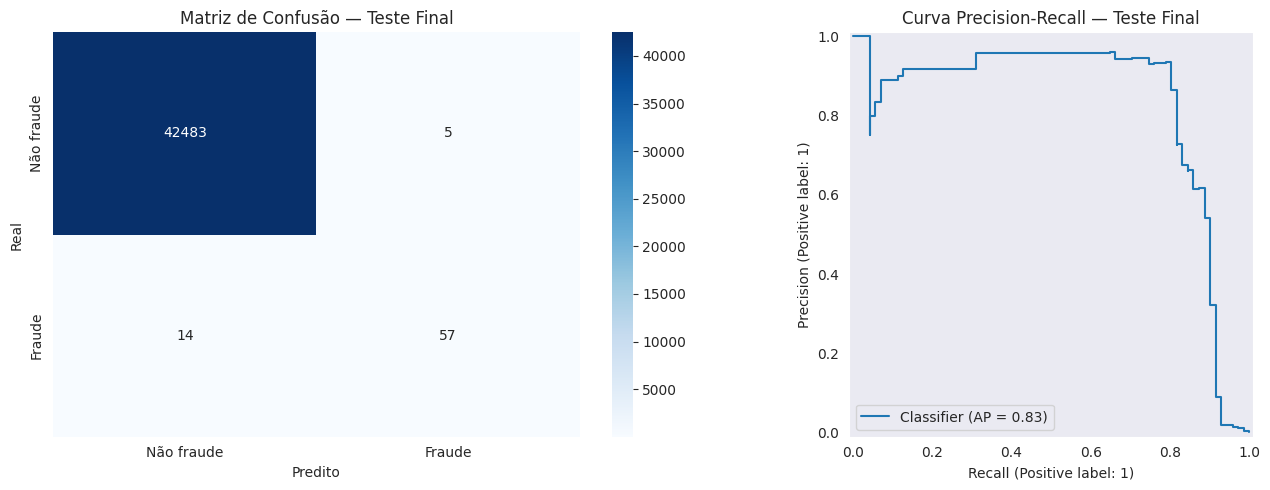

In [26]:
# ── Probabilidades no conjunto de teste ──────────────────────
y_proba_test = calibrated_lr.predict_proba(X_test)[:, 1]

# ── Aplica o threshold encontrado na validação ───────────────
y_pred_test = (y_proba_test >= threshold_lr).astype(int)

# ── Métricas finais ──────────────────────────────────────────
print("=" * 55)
print(" AVALIAÇÃO FINAL — Conjunto de Teste")
print("=" * 55)
print(f"Threshold aplicado : {threshold_lr:.2f}")
print(f"AUC-ROC            : {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"AUC-PR             : {average_precision_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, digits=4))

# ── Visualizações finais ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não fraude', 'Fraude'],
            yticklabels=['Não fraude', 'Fraude'])
axes[0].set_title('Matriz de Confusão — Teste Final')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_test, ax=axes[1]
)
axes[1].set_title('Curva Precision-Recall — Teste Final')

plt.tight_layout()
plt.show()

## **Avaliação Final: Conjunto de Teste**

O conjunto de teste permaneceu bloqueado durante todo o desenvolvimento, nenhuma decisão de modelagem, calibração ou threshold foi baseada nele. O threshold de 0.45, encontrado na validação, foi aplicado diretamente sem qualquer ajuste.

Resultados consistentes ou melhores que os da validação confirmam que o pipeline generalizou bem e que não houve data leakage em nenhuma etapa.

---

### **Resultados**

| Métrica | Validação | Teste |
|---|---|---|
| AUC-ROC | 0.9715 | **0.9885** |
| AUC-PR | 0.7434 | **0.8259** |
| Precision (fraude) | 88.41% | **91.94%** |
| Recall (fraude) | 76.25% | **80.28%** |
| F1 (fraude) | 0.8188 | **0.8571** |
| Falsos positivos | 8 | **5** |
| Fraudes detectadas | 61 de 80 | **57 de 71** |

Os resultados no teste superaram os da validação em todas as métricas, o que é incomum e indica ausência de overfitting. De 71 fraudes reais, o modelo detectou 57 gerando apenas 5 falsos alarmes. A cada 62 alertas disparados, 57 são fraudes reais (precision de 91.94% que torna o modelo operacionalmente viável em produção).

A curva Precision-Recall confirma a robustez do modelo: a precisão
se mantém acima de 0.90 para recall de até 0.80, o que significa
que o threshold de 0.45 opera numa região estável e pequenas
variações no ponto de corte não degradam abruptamente o desempenho.